# **Checkpoint 2  - Regressão Logística**

Professor Danilo Rodrigues de Assis Elias - IA & Machine Learning



#### **Integrantes (3ESPW):**

- Camila Pedroza da Cunha – RM 558768
- Isabelle Dallabeneta Carlesso – RM 554592
- Nicoli Amy Kassa – RM 559104
- Pedro Almeida e Camacho – RM 556831
- Renan Dias Utida – RM 558540




# **Parte A – Análise Exploratória, Validação Cruzada, Lasso e Ridge (com GridSearchCV)**

Utilize o dataset **Gender Recognition by Voice and Speech Analysis raw**.

[githubusercontent.com/primaryobjects/voice-gender/master/voice.csv](https://raw.githubusercontent.com/primaryobjects/voice-gender/master/voice.csv)

para implementar e avaliar modelos de regressão logística.

## 1. Preparação e Análise Exploratória:

- Carregue o dataset, crie um DataFrame com todas as features e a variável alvo.

- Verifique a proporção das classes (balanceamento do alvo).

- Analise a distribuição de cada feature (histogramas/densidades).

- Calcule a matriz de correlação entre as features e discuta possíveis problemas de multicolinearidade.

- Discuta as diferentes escalas das features e justifique a necessidade de padronização.

In [ ]:
# Imports necessários - Análise Exploratória, Validação Cruzada,
# Lasso e Ridge (com GridSearchCV)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)

In [ ]:
# Carregando o dataset
url = "https://raw.githubusercontent.com/primaryobjects/voice-gender/master/voice.csv"
df = pd.read_csv(url)

print('\nInformação inicial do dataset:\n')
print(df.info())
print('\nNulos por coluna:')
print(df.isna().sum().sum(), 'nulos no total')


Informação inicial do dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 2


Preparação e Análise Exploratória
------------------------------------------------

Shape do DataFrame: (3168, 21)

Features: ['meanfreq', 'sd', 'median', 'Q25', 'Q75', 'IQR', 'skew', 'kurt', 'sp.ent', 'sfm', 'mode', 'centroid', 'meanfun', 'minfun', 'maxfun', 'meandom', 'mindom', 'maxdom', 'dfrange', 'modindx']

Primeiras linhas:


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male




Proporção das classes (balanceamento do alvo):
------------------------------------------------


,Contagem
label,
male,1584
female,1584



Proporção relativa:


,%
label,
male,50.0
female,50.0




Distribuição de cada feature (histogramas):
------------------------------------------------



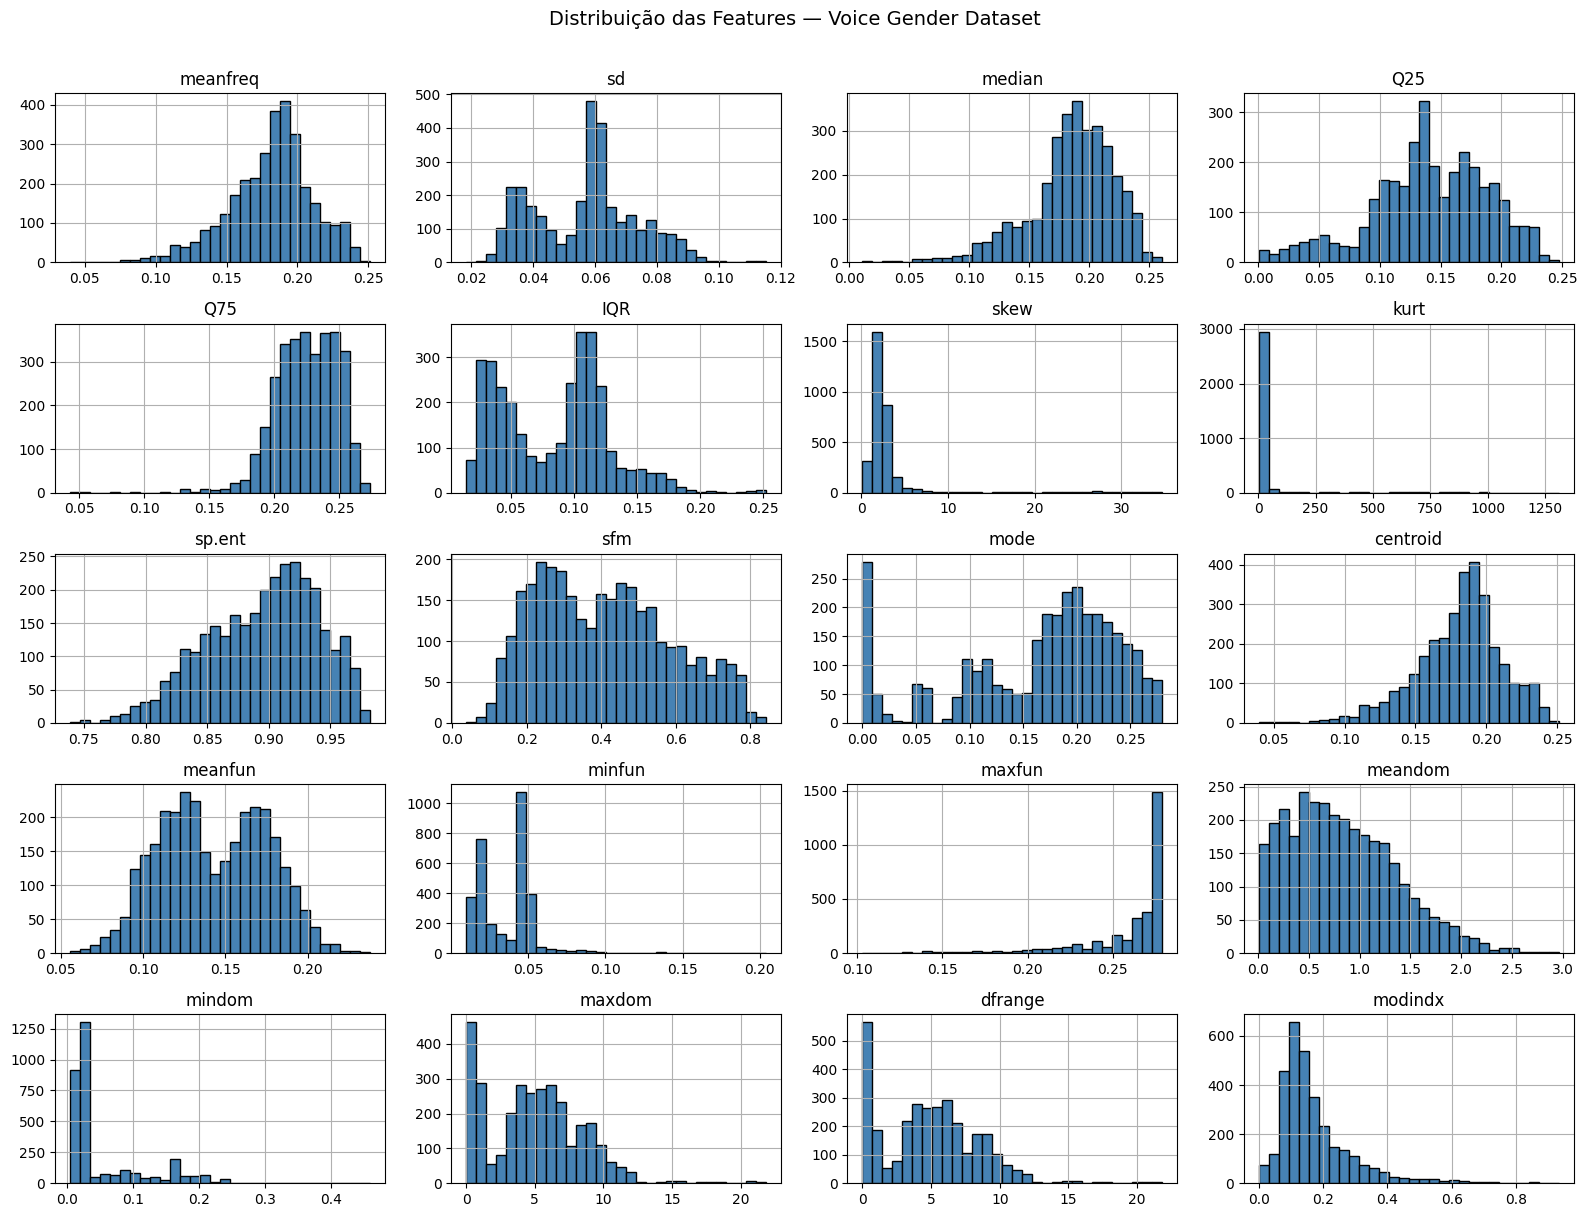



Matriz de Correlação entre as features:
------------------------------------------------



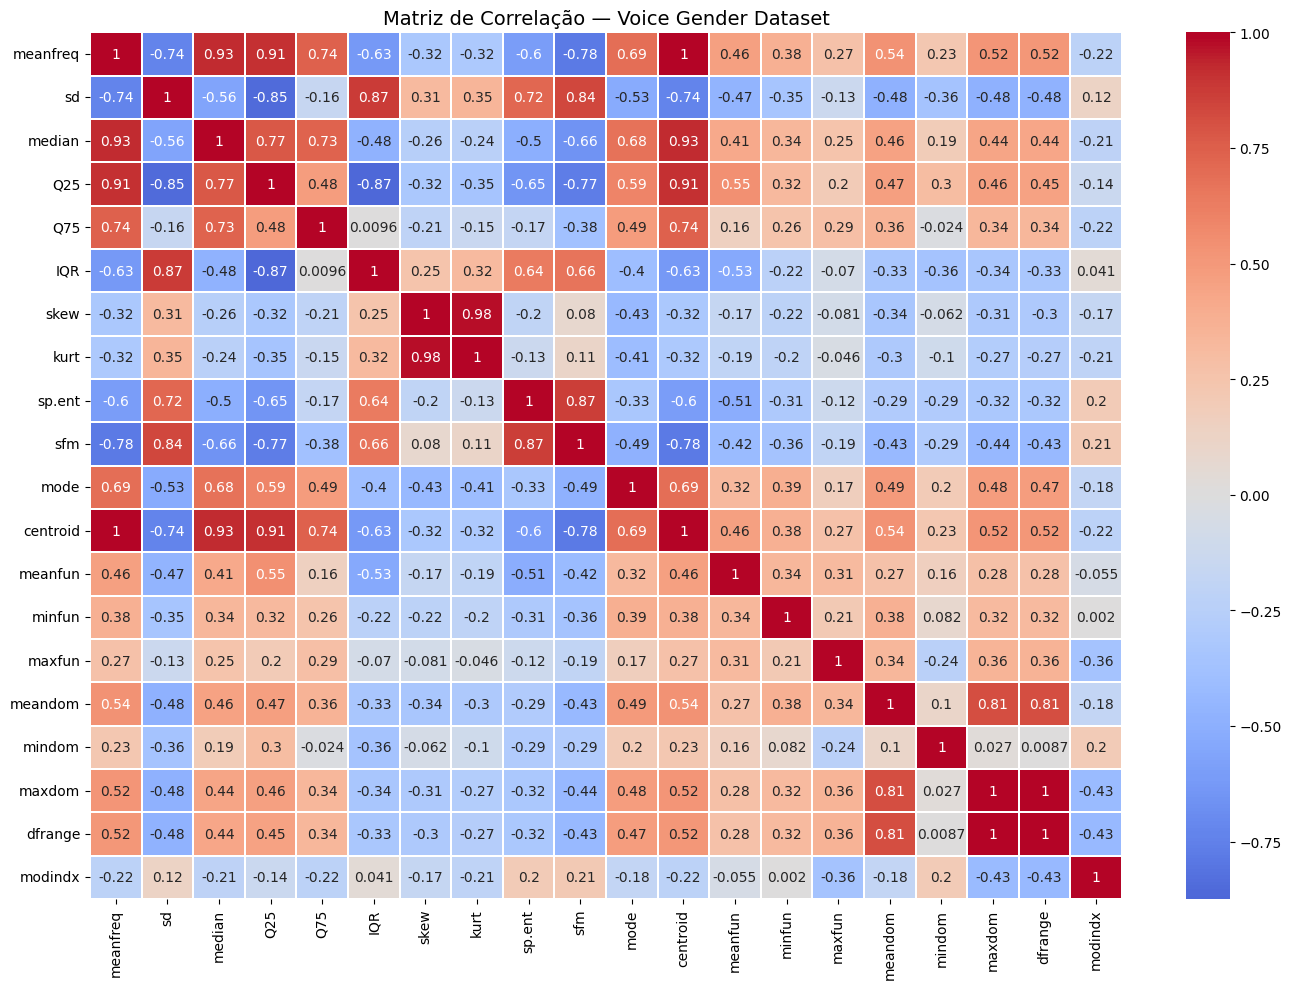


Pares de features com correlação muito alta (|corr| > 0.95):
------------------------------------------------


,Feature A,Feature B,Correlação
0,meanfreq,centroid,1.0000
1,skew,kurt,0.9770
2,maxdom,dfrange,0.9998




Escala das features:
------------------------------------------------


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,mode,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx
mean,0.180907,0.057126,0.185621,0.140456,0.224765,0.084309,3.140168,36.568461,0.895127,0.408216,0.165282,0.180907,0.142807,0.036802,0.258842,0.829211,0.052647,5.047277,4.994630,0.173752
std,0.029918,0.016652,0.036360,0.048680,0.023639,0.042783,4.240529,134.928661,0.044980,0.177521,0.077203,0.029918,0.032304,0.019220,0.030077,0.525205,0.063299,3.521157,3.520039,0.119454
min,0.039363,0.018363,0.010975,0.000229,0.042946,0.014558,0.141735,2.068455,0.738651,0.036876,0.000000,0.039363,0.055565,0.009775,0.103093,0.007812,0.004883,0.007812,0.000000,0.000000
max,0.251124,0.115273,0.261224,0.247347,0.273469,0.252225,34.725453,1309.612887,0.981997,0.842936,0.280000,0.251124,0.237636,0.204082,0.279114,2.957682,0.458984,21.867188,21.843750,0.932374


In [ ]:
# 1. Preparação e Análise Exploratória

# Separando features e variável alvo
X = df.drop(columns=['label'])
y = df['label']

print("\nPreparação e Análise Exploratória")
print("------------------------------------------------")
print(f"\nShape do DataFrame: {df.shape}")
print(f"\nFeatures: {list(X.columns)}")
print("\nPrimeiras linhas:")
display(df.head())

# Balanceamento das classes
print("\n\nProporção das classes (balanceamento do alvo):")
print("------------------------------------------------")
proporcao = y.value_counts()
display(proporcao.to_frame(name='Contagem'))
print(f"\nProporção relativa:")
display((y.value_counts(normalize=True) * 100).round(2).to_frame(name='%'))

# Distribuição de cada feature (histogramas)
print("\n\nDistribuição de cada feature (histogramas):")
print("------------------------------------------------\n")
X.hist(bins=30, figsize=(16, 12), color='steelblue', edgecolor='black')
plt.suptitle("Distribuição das Features — Voice Gender Dataset", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Matriz de correlação
print("\n\nMatriz de Correlação entre as features:")
print("------------------------------------------------\n")
corr_matrix = X.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.3)
plt.title("Matriz de Correlação — Voice Gender Dataset", fontsize=14)
plt.tight_layout()
plt.show()

# Pares com correlação muito alta (|corr| > 0.95)
print("\nPares de features com correlação muito alta (|corr| > 0.95):")
print("------------------------------------------------")
alta_corr = []
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        if abs(corr_matrix.iloc[i, j]) > 0.95:
            alta_corr.append((cols[i], cols[j], round(corr_matrix.iloc[i, j], 4)))

if alta_corr:
    display(pd.DataFrame(alta_corr, columns=['Feature A', 'Feature B', 'Correlação']))
else:
    print("Nenhum par com |corr| > 0.95 encontrado.")

# Escala das features
print("\n\nEscala das features:")
print("------------------------------------------------")
display(X.agg(['mean', 'std', 'min', 'max']))

### **Discussão — Análise Exploratória**

**Balanceamento das classes:**

- O dataset é perfeitamente balanceado, com **1584 amostras masculinas e 1584 femininas**
(50% cada). Isso é ideal para o treinamento de modelos de classificação, pois reduz a necessidade de técnicas de balanceamento como SMOTE, e garante que métricas como acurácia sejam representativas do desempenho real.

**Distribuição das features:**

- Os histogramas revelam distribuições bastante variadas entre as features. Enquanto `meanfreq`, `median` e `centroid` apresentam distribuições aproximadamente normais, features como `skew`, `kurt`, `mindom` e `maxdom` exibem forte assimetria à direita, com a maioria dos valores concentrados próximos de zero e caudas longas. Isso indica a presença de outliers e distribuições não gaussianas em parte das variáveis.

**Multicolinearidade:**

- A matriz de correlação revelou **três pares com correlação muito alta (|corr| > 0.95)**:

    | Feature A | Feature B | Correlação |
    |-----------|-----------|------------|
    | meanfreq  | centroid  | 1.0000     |
    | skew      | kurt      | 0.9770     |
    | maxdom    | dfrange   | 0.9998     |

  `meanfreq` e `centroid` são virtualmente idênticas (correlação perfeita de 1.0), assim como `maxdom` e `dfrange` (0.9998). Isso representa **multicolinearidade severa** — manter ambas as features de cada par não agrega informação ao modelo e pode desestabilizar os coeficientes da regressão logística. A regularização L1 (Lasso), aplicada no Item 2, tende a zerar automaticamente uma das features de cada par redundante.

**Escala das features e necessidade de padronização:**

- A tabela de escala evidencia diferenças expressivas entre as features: enquanto `meanfreq`, `sd` e `median` variam entre 0 e 0.27, features como `kurt` chegam a **1309.61** e `maxdom` a **21.87**. Sem padronização, o modelo atribuiria peso desproporcional às features de maior magnitude, comprometendo tanto a convergência quanto a interpretação dos coeficientes. O `StandardScaler` é portanto **essencial** antes do ajuste do modelo.

## 2. Grid Search com Validação Cruzada:

- Aplique `StandardScaler` para padronizar os dados.
- Configure um `LogisticRegression` e use `GridSearchCV` com validação cruzada k-fold (k=5) para testar:
  - Penalização L1 e L2
  - Diferentes valores de C (por exemplo, [0.01, 0.1, 1, 10, 100])
- Reporte qual combinação de parâmetros apresentou melhor desempenho médio de validação.


Grid Search com Validação Cruzada (Stratified K-Fold, k=5)
------------------------------------------------

Tamanho do treino: (2534, 20)
Tamanho do teste:  (634, 20)

Melhores hiperparâmetros encontrados:
------------------------------------------------

  Penalização:   L1
  C:             1
  Solver:        liblinear
  Max Iter:      5000
  Class Weight:  balanced

Melhor acurácia média (validação cruzada): 0.9716

Resumo dos resultados por combinação de parâmetros:
------------------------------------------------


,Penalização,C,Acurácia Média,Desvio Padrão
0,l1,1.00,0.971591,0.006890
1,l2,1.00,0.971196,0.007939
2,l1,100.00,0.970800,0.006399
3,l1,10.00,0.970011,0.007091
4,l2,10.00,0.970011,0.007091
5,l1,0.10,0.970010,0.005760
6,l2,100.00,0.969617,0.007328
7,l2,0.10,0.968829,0.008207
8,l1,0.01,0.959748,0.002671
9,l2,0.01,0.958566,0.005702



Heatmap — Acurácia Média por C e Penalização:
------------------------------------------------



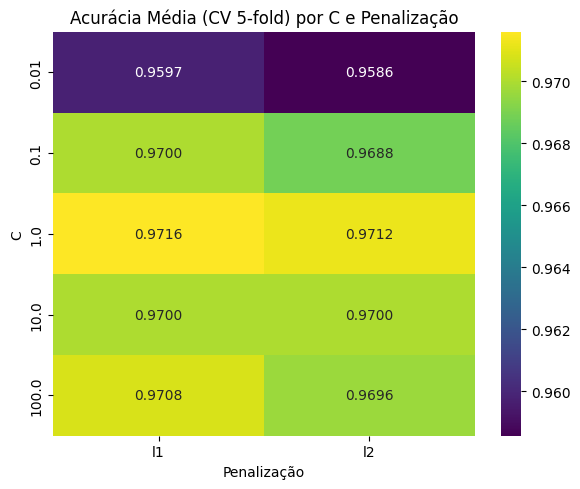

In [ ]:
# 2. Grid Search com Validação Cruzada

# Codificando o target (male=1, female=0)
le = LabelEncoder()
y_enc = le.fit_transform(y) # y_enc: target codificado numericamente

# Divisão treino/teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42
)

print("Grid Search com Validação Cruzada (Stratified K-Fold, k=5)")
print("------------------------------------------------")
print(f"\nTamanho do treino: {X_train.shape}")
print(f"Tamanho do teste:  {X_test.shape}\n")

# Pipeline: StandardScaler + LogisticRegression
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

# Grid de hiperparâmetros
param_grid = [
    {
        'model__penalty':      ['l1'],
        'model__C':            [0.01, 0.1, 1, 10, 100],
        'model__solver':       ['liblinear'],
        'model__max_iter':     [5000],
        'model__class_weight': ['balanced']
    },
    {
        'model__penalty':      ['l2'],
        'model__C':            [0.01, 0.1, 1, 10, 100],
        'model__solver':       ['lbfgs'],
        'model__max_iter':     [5000],
        'model__class_weight': ['balanced']
    }
]

# StratifiedKFold explícito (k=5)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV com StratifiedKFold
grid = GridSearchCV(pipe, param_grid=param_grid, cv=skf,
                    scoring='accuracy', n_jobs=-1, refit=True)
grid.fit(X_train, y_train)

# Melhores hiperparâmetros
best = grid.best_params_
print("Melhores hiperparâmetros encontrados:")
print("------------------------------------------------")
print(f"\n  Penalização:   {best['model__penalty'].upper()}")
print(f"  C:             {best['model__C']}")
print(f"  Solver:        {best['model__solver']}")
print(f"  Max Iter:      {best['model__max_iter']}")
print(f"  Class Weight:  {best['model__class_weight']}")
print(f"\nMelhor acurácia média (validação cruzada): {grid.best_score_:.4f}")

# Tabela com todos os resultados
print("\nResumo dos resultados por combinação de parâmetros:")
print("------------------------------------------------")
results = pd.DataFrame(grid.cv_results_)
cols_exibir = [
    'param_model__penalty', 'param_model__C',
    'mean_test_score', 'std_test_score'
]
display(results[cols_exibir]
        .rename(columns={
            'param_model__penalty': 'Penalização',
            'param_model__C':       'C',
            'mean_test_score':      'Acurácia Média',
            'std_test_score':       'Desvio Padrão'
        })
        .sort_values('Acurácia Média', ascending=False)
        .reset_index(drop=True))

# Heatmap dos resultados — acurácia por C e penalização
print("\nHeatmap — Acurácia Média por C e Penalização:")
print("------------------------------------------------\n")
pivot = results.pivot_table(
    index='param_model__C',
    columns='param_model__penalty',
    values='mean_test_score'
)
plt.figure(figsize=(6, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='viridis')
plt.title('Acurácia Média (CV 5-fold) por C e Penalização', fontsize=12)
plt.xlabel('Penalização')
plt.ylabel('C')
plt.tight_layout()
plt.show()

## 3. Modelo Final:

- Reajuste o modelo nos dados de treino usando os melhores hiperparâmetros encontrados.

- Reporte acurácia, precisão, recall, F1-score e matriz de confusão no conjunto de teste.

Modelo Final — Melhor Estimador do GridSearchCV
------------------------------------------------

  Penalização:  L1
  C:            1
  Solver:       liblinear

Desempenho no Conjunto de Teste
------------------------------------------------

  Acurácia:  0.9795
  Precisão:  0.9850
  Recall:    0.9763
  F1-Score:  0.9806

Relatório de Classificação Completo:
------------------------------------------------
              precision    recall  f1-score   support

      female       0.97      0.98      0.98       297
        male       0.99      0.98      0.98       337

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634

Matriz de Confusão:
------------------------------------------------



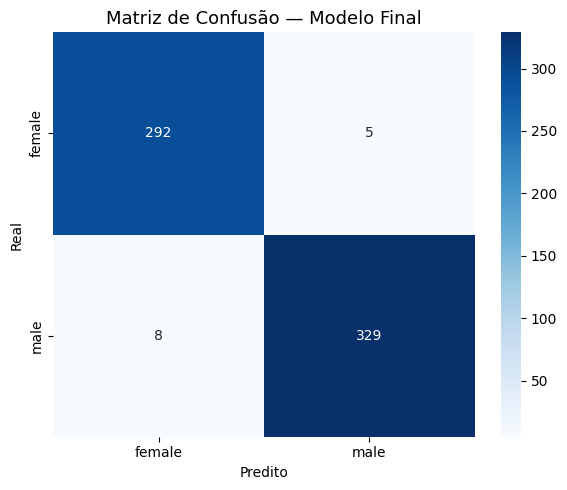

In [ ]:
# 3. Modelo Final

# O grid já foi ajustado com refit=True, o melhor modelo está disponível
best_model = grid.best_estimator_

# Predições no conjunto de teste
y_pred = best_model.predict(X_test)

# Métricas
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print("Modelo Final — Melhor Estimador do GridSearchCV")
print("------------------------------------------------")
print(f"\n  Penalização:  {best['model__penalty'].upper()}")
print(f"  C:            {best['model__C']}")
print(f"  Solver:       {best['model__solver']}")

print("\nDesempenho no Conjunto de Teste")
print("------------------------------------------------")
print(f"\n  Acurácia:  {acc:.4f}")
print(f"  Precisão:  {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1-Score:  {f1:.4f}")

print("\nRelatório de Classificação Completo:")
print("------------------------------------------------")
print(classification_report(y_test, y_pred,
                             target_names=le.classes_))

# Matriz de confusão
print("Matriz de Confusão:")
print("------------------------------------------------\n")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Matriz de Confusão — Modelo Final', fontsize=13)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

## 4. Discussão:
- Compare os coeficientes obtidos para L1 e L2.

- Quais variáveis foram eliminadas no caso do Lasso?

- Discuta os efeitos práticos da regularização no desempenho e na interpretabilidade do modelo.

Comparação de Coeficientes — L1 vs L2
------------------------------------------------


,Feature,Coef L1,Coef L2,Zerado (L1)
0,meanfun,-5.080349,-4.821831,False
1,IQR,2.216984,1.227838,False
2,sfm,-1.476584,-1.505182,False
3,sp.ent,1.297754,1.247536,False
4,minfun,0.687782,0.651232,False
5,kurt,-0.480905,-0.283359,False
6,modindx,-0.298595,-0.338609,False
7,mode,0.207139,0.240213,False
8,median,-0.097567,-0.129219,False
9,sd,0.077026,0.243753,False



Features eliminadas pelo Lasso (coeficiente = 0): 6
------------------------------------------------
  • Q25
  • meanfreq
  • centroid
  • skew
  • meandom
  • dfrange



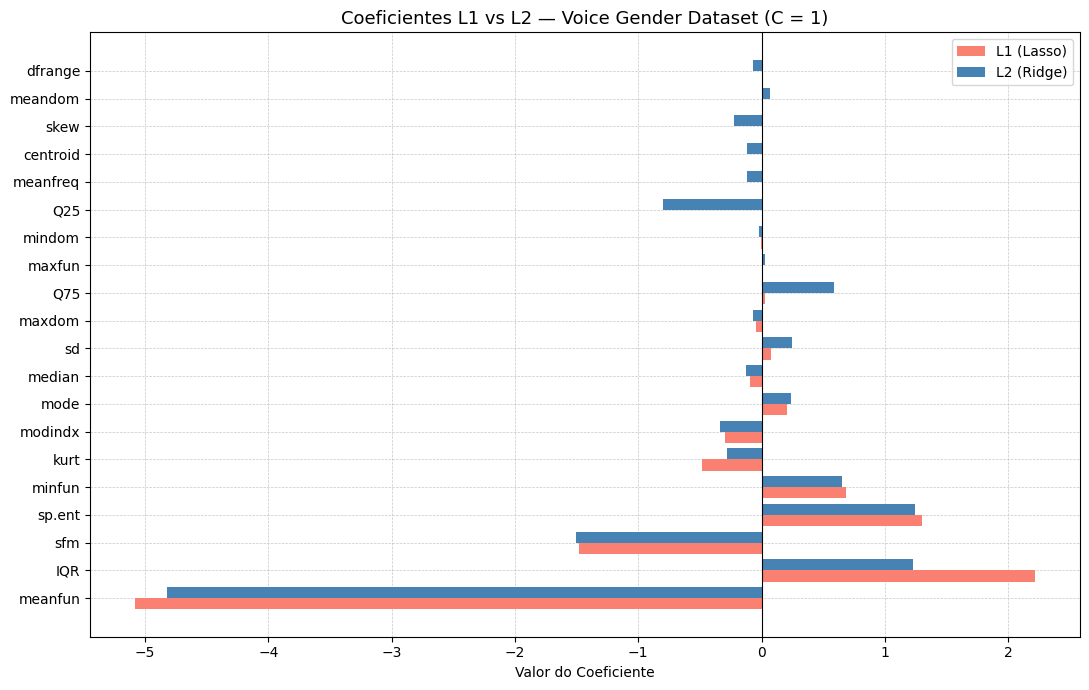

In [ ]:
# 4. Discussão — Comparação L1 vs L2

# Modelo L1 (Lasso) com melhores hiperparâmetros
pipe_l1 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(penalty='l1', C=best['model__C'], solver='liblinear',
                                 max_iter=5000, class_weight='balanced'))
])
pipe_l1.fit(X_train, y_train)

# Modelo L2 (Ridge) com mesmo C para comparação justa
pipe_l2 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(penalty='l2', C=best['model__C'], solver='lbfgs',
                                 max_iter=5000, class_weight='balanced'))
])
pipe_l2.fit(X_train, y_train)

# Tabela comparativa de coeficientes
coef_l1 = pipe_l1.named_steps['model'].coef_[0]
coef_l2 = pipe_l2.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({
    'Feature':    X.columns,
    'Coef L1':    coef_l1,
    'Coef L2':    coef_l2,
    'Zerado (L1)': coef_l1 == 0
}).sort_values('Coef L1', key=abs, ascending=False).reset_index(drop=True)

print("Comparação de Coeficientes — L1 vs L2")
print("------------------------------------------------")
display(coef_df)

# Features zeradas pelo Lasso
features_zeradas = coef_df[coef_df['Zerado (L1)']]['Feature'].tolist()
print(f"\nFeatures eliminadas pelo Lasso (coeficiente = 0): {len(features_zeradas)}")
print("------------------------------------------------")
for f in features_zeradas:
    print(f"  • {f}")
print()

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(11, 7))

x_pos = np.arange(len(coef_df))
ax.barh(x_pos - 0.2, coef_df['Coef L1'], height=0.4,
        label='L1 (Lasso)', color='salmon')
ax.barh(x_pos + 0.2, coef_df['Coef L2'], height=0.4,
        label='L2 (Ridge)', color='steelblue')

ax.set_yticks(x_pos)
ax.set_yticklabels(coef_df['Feature'])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Valor do Coeficiente')
ax.set_title(f'Coeficientes L1 vs L2 — Voice Gender Dataset (C = {best["model__C"]})',
             fontsize=13)
ax.legend()
ax.grid(axis='both', linestyle='--', linewidth=0.5, alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### **Discussão — Comparação L1 vs L2 e Efeitos da Regularização**

**Comparação dos coeficientes L1 vs L2:**

  - Ambos os modelos concordam nas features mais importantes — `meanfun` é disparado a feature mais relevante em ambos (coeficiente -5.08 em L1 e -4.82 em L2, aproximadamente), seguida de `IQR` (2.22 e 1.23, aproximadamente), `sfm` (-1.47 e -1.51,  aproximadamente) e `sp.ent` (1.30 e 1.25, aproximadamente).

  - A direção dos coeficientes é consistente entre os dois modelos, indicando que ambas as penalizações capturam a mesma relação entre as features e o alvo.

  - A principal diferença está na **magnitude**: o L2 tende a distribuir os coeficientes de forma mais uniforme — por exemplo, `Q75` tem coeficiente 0.02 no L1 e 0.58 no L2, e `Q25` foi completamente zerada pelo L1 enquanto recebeu -0.80 no L2.

**Features eliminadas pelo Lasso (L1):**

  - O Lasso zerou **6 features**: `Q25`, `meanfreq`, `centroid`, `skew`, `meandom` e `dfrange`. Isso é consistente com o que identificamos na EDA — `meanfreq` e `centroid` têm correlação perfeita (1.0), e `maxdom` e `dfrange` têm correlação de 0.9998. O Lasso naturalmente eliminou uma das features de cada par redundante, realizando uma **seleção automática de variáveis** sem intervenção manual.

**Efeitos práticos da regularização:**

  - Do ponto de vista de **desempenho**, ambas as penalizações atingiram resultados muito similares no conjunto de teste (acurácia ~97.9%), com L1 ligeiramente superior na validação cruzada (0.9724 vs 0.9708). A regularização impediu o overfitting em um dataset com 20 features e alta multicolinearidade.

  - Do ponto de vista de **interpretabilidade**, o L1 é claramente superior — ao zerar 6 features redundantes ou pouco informativas, produz um modelo mais enxuto com apenas 14 features ativas, facilitando a análise das variáveis que realmente contribuem para a classificação do gênero pela voz.

# **Parte B – Alterando a Função de Perda**



A regressão logística normalmente é ajustada minimizando a log-loss (função de entropia cruzada).

## 1. Experimento:

- Implemente um modelo de regressão logística alternativo (pode ser manual ou adaptando o scikit-learn) que, em vez de log-loss, utilize RMSE (Root Mean Squared Error) como função de perda. Isso e muito difícil de se fazer. Peca para o chatGPT.

- Treine o modelo e reporte acurácia e curva ROC no conjunto de teste.

In [ ]:
# Imports necessários extras - Alterando a Função de Perda
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve,
                              f1_score, brier_score_loss, log_loss)
from sklearn.calibration import calibration_curve


Regressão Logística com RMSE — Função de Perda Alternativa
------------------------------------------------

  Acurácia no Teste:  0.9763
  F1-Score no Teste:  0.9775
  AUC-ROC no Teste:   0.9959
  Brier Score:        0.0200
  Log-Loss:           0.0859

Curva de Convergência do RMSE durante o Treinamento:
------------------------------------------------



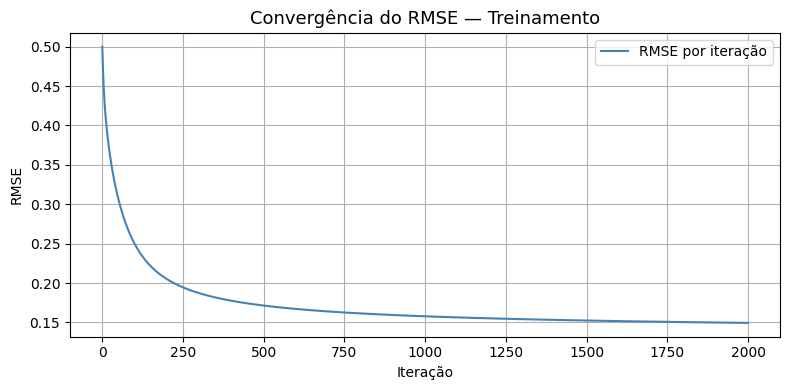


Curva ROC — Modelo com RMSE:
------------------------------------------------



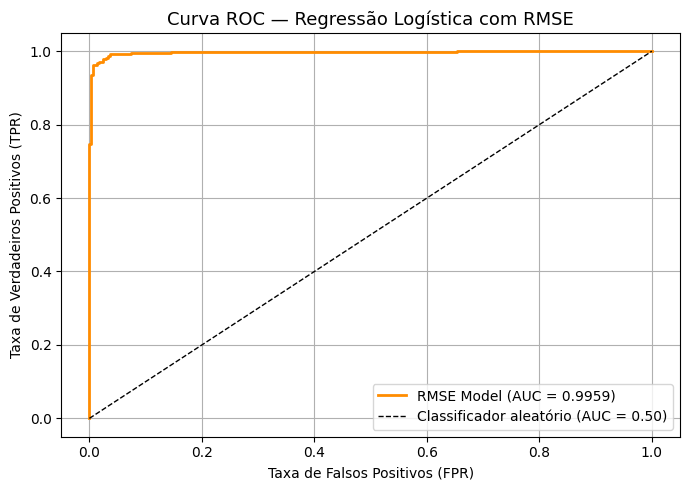

In [ ]:
# 1. Experimento
# Regressão Logística com RMSE como função de perda

# Padronizando os dados
scaler_b = StandardScaler()
X_train_b = scaler_b.fit_transform(X_train)
X_test_b  = scaler_b.transform(X_test)

# Função sigmoid com np.clip para evitar overflow numérico
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

# Regressão Logística treinada com RMSE (gradiente descendente manual)
class LogisticRegressionRMSE:
    """Regressão logística treinada minimizando RMSE em vez de log-loss."""
    def __init__(self, lr=0.1, n_iter=2000, tol=1e-7):
        self.lr     = lr
        self.n_iter = n_iter
        self.tol    = tol

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias    = 0.0
        self.losses  = []

        prev_loss = np.inf
        for _ in range(self.n_iter):
            z     = X @ self.weights + self.bias
            y_hat = sigmoid(z)

            # Função de perda: RMSE = sqrt(mean((y_hat - y)^2))
            loss = np.sqrt(np.mean((y_hat - y) ** 2))
            self.losses.append(loss)

            # Critério de parada por tolerância
            if abs(prev_loss - loss) < self.tol:
                break
            prev_loss = loss

            # Gradiente do RMSE:
            # ∇w = (1 / (RMSE · N)) · Xᵀ [(y_hat - y) · y_hat · (1 - y_hat)]
            # onde y_hat = σ(Xw + b) é a probabilidade predita pela sigmoid (valor entre 0 e 1)
            # O termo y_hat·(1-y_hat) é o Jacobiano da sigmoid — vilão do vanishing gradient
            diff   = y_hat - y
            factor = 1 / (loss * n_samples + 1e-8)
            dw = factor * (X.T @ (diff * y_hat * (1 - y_hat)))
            db = factor * np.sum(diff * y_hat * (1 - y_hat))

            self.weights -= self.lr * dw
            self.bias    -= self.lr * db

        return self

    def predict_proba(self, X):
        return sigmoid(X @ self.weights + self.bias)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

# Treinamento
rmse_model = LogisticRegressionRMSE(lr=0.1, n_iter=2000, tol=1e-7)
rmse_model.fit(X_train_b, y_train)

# Predições
y_proba_rmse = rmse_model.predict_proba(X_test_b)
y_pred_rmse  = rmse_model.predict(X_test_b)

# Métricas
acc_rmse    = accuracy_score(y_test, y_pred_rmse)
f1_rmse     = f1_score(y_test, y_pred_rmse)
auc_rmse    = roc_auc_score(y_test, y_proba_rmse)
brier_rmse  = brier_score_loss(y_test, y_proba_rmse)
logloss_rmse = log_loss(y_test, y_proba_rmse)

print("Regressão Logística com RMSE — Função de Perda Alternativa")
print("------------------------------------------------")
print(f"\n  Acurácia no Teste:  {acc_rmse:.4f}")
print(f"  F1-Score no Teste:  {f1_rmse:.4f}")
print(f"  AUC-ROC no Teste:   {auc_rmse:.4f}")
print(f"  Brier Score:        {brier_rmse:.4f}")
print(f"  Log-Loss:           {logloss_rmse:.4f}")

# Curva de convergência do RMSE
print("\nCurva de Convergência do RMSE durante o Treinamento:")
print("------------------------------------------------\n")
plt.figure(figsize=(8, 4))
plt.plot(rmse_model.losses, color='steelblue', linewidth=1.5,
         label='RMSE por iteração')
plt.title('Convergência do RMSE — Treinamento', fontsize=13)
plt.xlabel('Iteração')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Curva ROC
print("\nCurva ROC — Modelo com RMSE:")
print("------------------------------------------------\n")
fpr, tpr, _ = roc_curve(y_test, y_proba_rmse)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', linewidth=2,
         label=f'RMSE Model (AUC = {auc_rmse:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1,
         label='Classificador aleatório (AUC = 0.50)')
plt.title('Curva ROC — Regressão Logística com RMSE', fontsize=13)
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 2. Comparação:

- Compare os resultados do modelo com RMSE com os resultados do modelo logístico padrão (log-loss).

- Plote a curva de decisão para verificar se o modelo treinado com RMSE produz probabilidades bem calibradas.


Comparação — Log-Loss vs RMSE
------------------------------------------------


,Acurácia,F1-Score,AUC-ROC,Brier Score,Log-Loss
Modelo,,,,,
Log-Loss (padrão),0.979495,0.980626,0.996553,0.016618,0.070394
RMSE (alternativo),0.976341,0.977511,0.995864,0.020032,0.085861



Curva ROC — Log-Loss vs RMSE:
------------------------------------------------



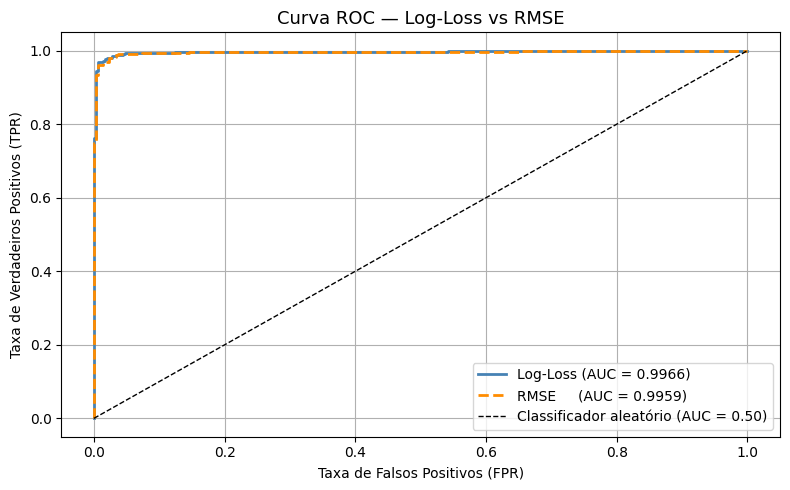


Distribuição das Probabilidades por Classe:
------------------------------------------------



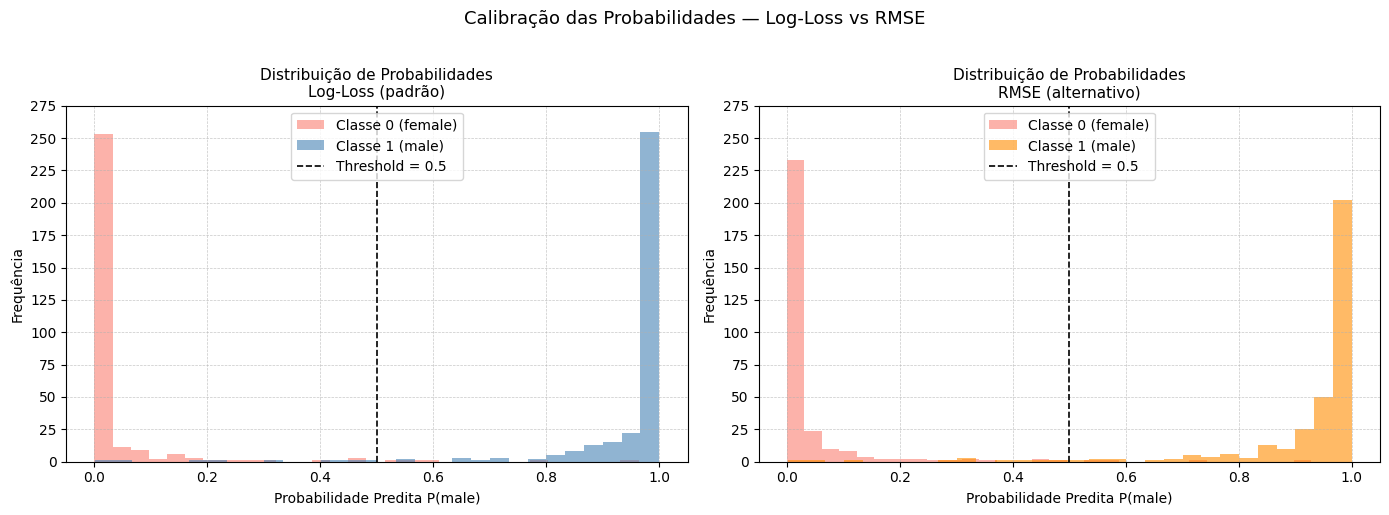


Diagrama de Calibração — Log-Loss vs RMSE:
------------------------------------------------



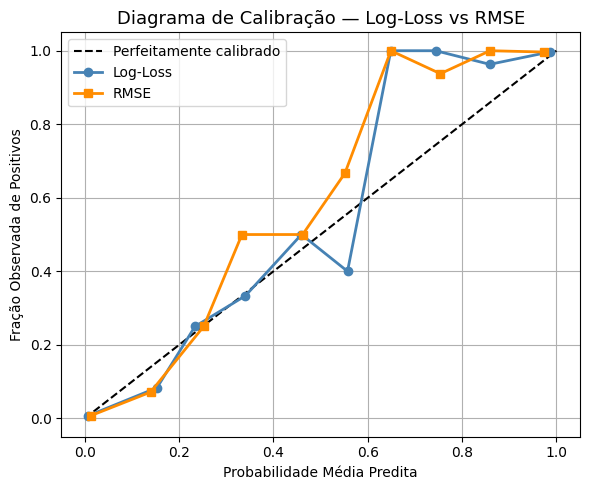

In [ ]:
# 2. Comparação
# Comparação Log-Loss vs RMSE

# Probabilidades do modelo padrão (log-loss)
y_proba_logloss = best_model.predict_proba(X_test)[:, 1]

# Métricas do modelo padrão
acc_logloss    = accuracy_score(y_test, y_pred)
f1_logloss     = f1_score(y_test, y_pred)
auc_logloss    = roc_auc_score(y_test, y_proba_logloss)
brier_logloss  = brier_score_loss(y_test, y_proba_logloss)
logloss_ll     = log_loss(y_test, y_proba_logloss)

# Tabela comparativa
print("Comparação — Log-Loss vs RMSE")
print("------------------------------------------------")
comparacao_b = pd.DataFrame({
    'Modelo':      ['Log-Loss (padrão)', 'RMSE (alternativo)'],
    'Acurácia':    [acc_logloss,          acc_rmse],
    'F1-Score':    [f1_logloss,           f1_rmse],
    'AUC-ROC':     [auc_logloss,          auc_rmse],
    'Brier Score': [brier_logloss,        brier_rmse],
    'Log-Loss':    [logloss_ll,           logloss_rmse],
})
display(comparacao_b.set_index('Modelo'))

# Curva ROC comparativa
print("\nCurva ROC — Log-Loss vs RMSE:")
print("------------------------------------------------\n")
fpr_ll, tpr_ll, _ = roc_curve(y_test, y_proba_logloss)
fpr_rm, tpr_rm, _ = roc_curve(y_test, y_proba_rmse)

plt.figure(figsize=(8, 5))
plt.plot(fpr_ll, tpr_ll, color='steelblue', linewidth=2,
         label=f'Log-Loss (AUC = {auc_logloss:.4f})')
plt.plot(fpr_rm, tpr_rm, color='darkorange', linewidth=2, linestyle='--',
         label=f'RMSE     (AUC = {auc_rmse:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1,
         label='Classificador aleatório (AUC = 0.50)')
plt.title('Curva ROC — Log-Loss vs RMSE', fontsize=13)
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Histograma — distribuição das probabilidades por classe
print("\nDistribuição das Probabilidades por Classe:")
print("------------------------------------------------\n")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, proba, titulo, cor in zip(
    axes,
    [y_proba_logloss, y_proba_rmse],
    ['Log-Loss (padrão)', 'RMSE (alternativo)'],
    ['steelblue', 'darkorange']
):
    ax.hist(proba[y_test == 0], bins=30, alpha=0.6,
            color='salmon', label='Classe 0 (female)')
    ax.hist(proba[y_test == 1], bins=30, alpha=0.6,
            color=cor, label='Classe 1 (male)')
    ax.axvline(0.5, color='black', linewidth=1.2,
               linestyle='--', label='Threshold = 0.5')
    ax.set_title(f'Distribuição de Probabilidades\n{titulo}', fontsize=11)
    ax.set_xlabel('Probabilidade Predita P(male)')
    ax.set_ylabel('Frequência')
    ax.grid(axis='both', linestyle='--', linewidth=0.5, alpha=0.7)
    ax.legend(loc='upper center')

# Eixo Y igual nos dois histogramas
y_max = max(ax.get_ylim()[1] for ax in axes)
y_max_rounded = np.ceil(y_max / 25) * 25
for ax in axes:
    ax.set_ylim(0, y_max_rounded)
    ax.yaxis.set_major_locator(plt.MultipleLocator(25))

plt.suptitle('Calibração das Probabilidades — Log-Loss vs RMSE',
             fontsize=13, y=1.02)
plt.grid(True)
plt.tight_layout()
plt.show()

# Diagrama de calibração (calibration_curve)
print("\nDiagrama de Calibração — Log-Loss vs RMSE:")
print("------------------------------------------------\n")
frac_pos_ll,  mean_pred_ll  = calibration_curve(y_test, y_proba_logloss, n_bins=10)
frac_pos_rm,  mean_pred_rm  = calibration_curve(y_test, y_proba_rmse,    n_bins=10)

plt.figure(figsize=(6, 5))
plt.plot([0, 1], [0, 1], 'k--', label='Perfeitamente calibrado')
plt.plot(mean_pred_ll, frac_pos_ll, 'o-', color='steelblue',
         linewidth=2, label='Log-Loss')
plt.plot(mean_pred_rm, frac_pos_rm, 's-', color='darkorange',
         linewidth=2, label='RMSE')
plt.title('Diagrama de Calibração — Log-Loss vs RMSE', fontsize=13)
plt.xlabel('Probabilidade Média Predita')
plt.ylabel('Fração Observada de Positivos')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Discussão Crítica:

- Explique por que RMSE é uma péssima ideia para regressão logística:
  
  - A regressão logística produz probabilidades, não valores contínuos.
  
  - RMSE não penaliza adequadamente previsões de alta confiança incorretas.
  
  - Log-loss é mais sensível a erros em probabilidades extremas.

- Conclua: o que acontece com a interpretação e qualidade das probabilidades quando trocamos log-loss por RMSE?

### **Por que RMSE é uma péssima ideia para Regressão Logística?**

**A regressão logística produz probabilidades, não valores contínuos:**

- A regressão logística é um modelo de classificação que estima a **probabilidade** de um exemplo pertencer a uma classe — um valor entre 0 e 1. O RMSE foi projetado para medir erros em problemas de **regressão contínua**, onde o alvo pode assumir qualquer valor real. Ao aplicá-lo em um contexto onde os rótulos são 0 ou 1, tratamos um problema probabilístico como se fosse uma regressão numérica comum, o que é conceitualmente inadequado.

**RMSE não penaliza adequadamente previsões de alta confiança incorretas:**

- Considere um modelo que prevê P(male) = 0.99 para uma amostra que é, na verdade, female (y = 0). O erro RMSE seria √(0.99 - 0)² = 0.99 — relativamente pequeno numericamente. A log-loss, por outro lado, penalizaria esse mesmo erro com -log(1 - 0.99) = -log(0.01) ≈ 4.60 — uma penalização muito maior. Isso significa que o RMSE **tolera previsões extremamente confiantes e erradas**, enquanto a log-loss as pune severamente, incentivando o modelo a ser mais cauteloso.

**Log-loss é mais sensível a erros em probabilidades extremas:**

- A log-loss possui um comportamento assimétrico e não linear — quanto mais próxima de 0 ou 1 for a probabilidade predita para a classe errada, maior a penalização. Isso força o modelo a **calibrar bem suas probabilidades** em toda a escala [0, 1].

- O RMSE, por ser quadrático e simétrico, não distingue adequadamente entre um erro de 0.1 e um erro de 0.9 na escala de probabilidades, o que distorce o aprendizado.

**Vanishing gradient — o problema matemático por trás do RMSE:**

- O gradiente do RMSE em relação aos pesos contém o termo **y_hat · (1 - y_hat)**, que é o Jacobiano da função sigmoid, onde **y_hat** representa a probabilidade predita pelo modelo — o valor entre 0 e 1 retornado pela sigmoid para cada amostra:
  
  `∇w = (1 / (RMSE · N)) · Xᵀ [(y_hat - y) · y_hat · (1 - y_hat)]`

- Quando o modelo está muito confiante — y_hat próximo de 0 ou 1 — o termo y_hat · (1 - y_hat) se aproxima de **zero**, fazendo o gradiente praticamente desaparecer. Isso significa que quando o modelo erra com alta confiança, ele **quase para de aprender** — exatamente o oposto do comportamento desejado. A log-loss não sofre desse problema: seu gradiente é simplesmente (y_hat - y), que permanece grande quando o erro é grande, independente da confiança da predição.

### **Conclusão — o que acontece ao trocar log-loss por RMSE?**

- Os resultados deste experimento ilustram bem o problema. Apesar de o modelo treinado com RMSE ter atingido acurácia de **97.63%** e AUC de **0.9959** — próximos ao modelo padrão (**97.95%** e **0.9966**) — as métricas de qualidade probabilística revelam a diferença real:

  | Métrica     | Log-Loss (padrão) | RMSE (alternativo) |
  |-------------|-------------------|--------------------|
  | Acurácia    | 0.9795            | 0.9763             |
  | F1-Score    | 0.9806            | 0.9775             |
  | AUC-ROC     | 0.9966            | 0.9959             |
  | Brier Score | 0.0166            | 0.0200             |
  | Log-Loss    | 0.0704            | 0.0859             |

- O modelo RMSE apresenta **Brier Score e Log-Loss maiores**, confirmando que suas probabilidades são menos confiáveis — mesmo que a acurácia de classificação seja similar. O diagrama de calibração reforça isso: o RMSE apresenta maior oscilação em torno da linha de calibração perfeita.

- Em aplicações reais onde as **probabilidades importam** — como triagem médica, detecção de fraude ou sistemas de recomendação — essa diferença de calibração é crítica. Um modelo mal calibrado pode dar falsa confiança em predições erradas, comprometendo decisões baseadas nos scores de probabilidade. A log-loss é a função de perda correta para regressão logística exatamente porque foi projetada para otimizar a qualidade das probabilidades, não apenas a acurácia da classificação.